Training Score 85.38294273979223
Testing Score 83.81642512077295

   Actual  Predicted
0       0          0
1       0          1
2       1          1
3       1          1
4       0          1
5       1          1
6       1          1
7       1          1
8       0          0
9       0          0

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1010
           1       0.79      0.94      0.86      1060

    accuracy                           0.84      2070
   macro avg       0.85      0.84      0.84      2070
weighted avg       0.85      0.84      0.84      2070



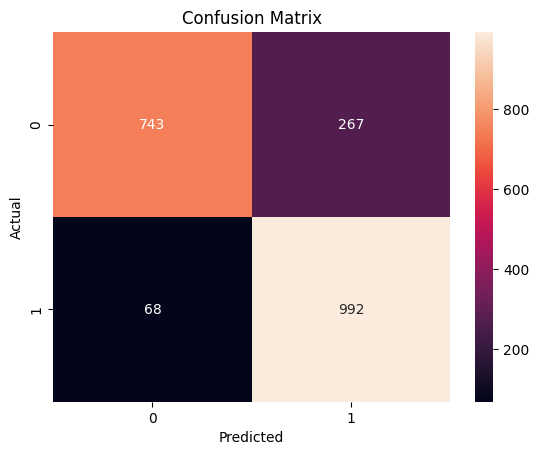

In [7]:
import pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score,precision_score,f1_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
import joblib
from xgboost import XGBClassifier

dataset=pd.read_csv(r"C:\Users\Saksham Awasthi\Downloads\Telco-Customer-Churn.csv")

x = dataset.iloc[:,:-1]
y = dataset["Churn"]
x = x.drop(columns = ["customerID"])

x["TotalCharges"] = pd.to_numeric(x["TotalCharges"],errors = 'coerce')
x["TotalCharges"] = x["TotalCharges"].fillna(x["TotalCharges"].median())

# ENCODING

la = LabelEncoder()

lst_cat = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
           'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

lst_num = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']


processor = ColumnTransformer(transformers =[
                        ('cat', OneHotEncoder(drop = 'first',handle_unknown = 'ignore'), lst_cat),

                        ('num', 'passthrough' ,lst_num)
                               ]
                )
                        
x = processor.fit_transform(x)


y = la.fit_transform(y)


# Balancing Data

balan = SMOTE(random_state = 40)
x_balan,y_balan = balan.fit_resample(x,y)

#TRAIN TEST SPLITTING

x_train,x_test,y_train,y_test = train_test_split(x_balan,y_balan,test_size = 0.2,random_state = 40)


# Training Model

model = XGBClassifier(n_estimators = 500,max_depth = 4,learning_rate = 0.03,scale_pos_weight = 3,
                      subsample = 0.8,min_child_weight = 5,gamma = 0.2)
                                       
model.fit(x_train,y_train)

prd = model.predict(x_test)

prd_output = pd.DataFrame({
                      'Actual': y_test,
                       'Predicted': prd,
                       
})

prd_output.to_csv('Actual_VS_Predicted.csv',index = False)

print("Training Score",model.score(x_train,y_train)*100)
print("Testing Score",model.score(x_test,y_test)*100)    
print("")

# Outputs
print(prd_output.head(10))
print("")



accuracy = accuracy_score(y_test,prd)
precision = precision_score(y_test,prd)
recall = recall_score(y_test,prd)
f1 = f1_score(y_test,prd)

with open("Mdoel_Score.txt","w") as f:
    f.write(f"Accuracy : {accuracy: .4f}\n")
    f.write(f"Precision : {precision: .4f}\n")
    f.write(f"Recall : {recall: .4f}\n")
    f.write(f"F1-score: {f1: .4f}\n")



report = classification_report(y_test,prd)
print(report)

with open('classification_report.txt','w') as f:
    f.write(report)

cm = confusion_matrix(y_test,prd)
sns.heatmap(cm,annot = True,fmt = 'd')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

#joblib.dump(model,"churn-Prediction.pkl")
